# BLE-RSSI-Analyse

## Ziel

Analyse der BLE-RSSI-Messungen für die spätere Sensorfusion im Particle Filter.

RSSI ist ein Maß für die empfangene Signalstärke in dBm. Höhere Werte
(z. B. -50 dBm) bedeuten ein stärkeres Signal als niedrigere Werte
(z. B. -90 dBm).

Die Analyse beantwortet:

1. Welche Beacons sind pro Run sichtbar?
2. Wie stark schwanken RSSI-Werte?
3. Welche Beacons liefern zuverlässig starke Signale?
4. Wie können RSSI-Werte als Gewichtung im Particle Filter genutzt werden?

Hinweis: RSSI wird nicht direkt als präzise Distanz verwendet. In einem
Gebäude beeinflussen Reflexionen, Personen, Wände und Smartphone-
Orientierung die Messwerte deutlich.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DB_PATH = Path("../data/emi_nav.db")
RUN_IDS = ["R1", "R2", "R3"]

# Fenster für zeitliche Aggregation:
# Median ist robust gegen einzelne RSSI-Ausreißer.
BIN_SIZE_S = 1.0

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [2]:
conn = sqlite3.connect(DB_PATH)

ble = pd.read_sql_query("""
    SELECT
        run_id,
        timestamp_ms,
        beacon_name,
        address,
        rssi
    FROM ble_rssi
    WHERE run_id IN ('R1', 'R2', 'R3')
      AND rssi IS NOT NULL
    ORDER BY run_id, timestamp_ms
""", conn)

conn.close()

ble["time_s"] = ble["timestamp_ms"] / 1000.0
ble["beacon_id"] = ble["beacon_name"].fillna(ble["address"])

print(f"BLE-Messungen: {len(ble):,}")
display(ble.head())

BLE-Messungen: 3,772


,run_id,timestamp_ms,beacon_name,address,rssi,time_s,beacon_id
0,R1,1781612173694,arrive_emi3,C0:46:B3:ED:0C:FC,-98.0,1.781612e+09,arrive_emi3
1,R1,1781612173776,arrive_emi4,F7:20:56:9D:E9:D4,-66.0,1.781612e+09,arrive_emi4
2,R1,1781612173893,arrive_emi4,F7:20:56:9D:E9:D4,-67.0,1.781612e+09,arrive_emi4
3,R1,1781612174013,arrive_emi4,F7:20:56:9D:E9:D4,-66.0,1.781612e+09,arrive_emi4
4,R1,1781612174136,arrive_emi4,F7:20:56:9D:E9:D4,-72.0,1.781612e+09,arrive_emi4


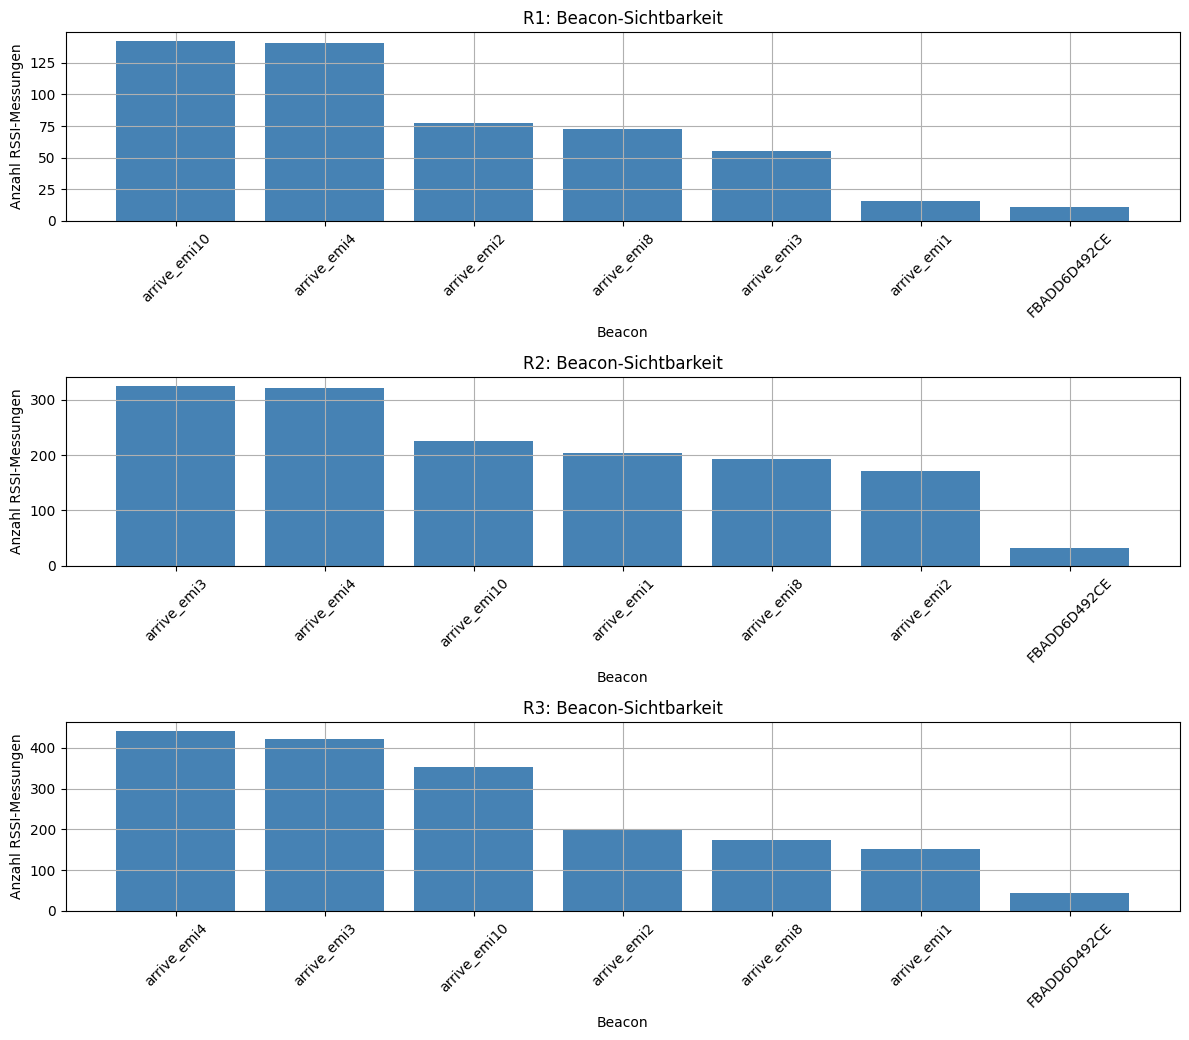

In [3]:
visibility = (
    ble.groupby(["run_id", "beacon_id"])
    .size()
    .reset_index(name="n_measurements")
)

fig, axes = plt.subplots(
    len(RUN_IDS),
    1,
    figsize=(12, 3.5 * len(RUN_IDS)),
    sharex=False,
)

for ax, run_id in zip(axes, RUN_IDS):
    run_visibility = (
        visibility[visibility["run_id"] == run_id]
        .sort_values("n_measurements", ascending=False)
    )

    ax.bar(
        run_visibility["beacon_id"],
        run_visibility["n_measurements"],
        color="steelblue",
    )
    ax.set_title(f"{run_id}: Beacon-Sichtbarkeit")
    ax.set_xlabel("Beacon")
    ax.set_ylabel("Anzahl RSSI-Messungen")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

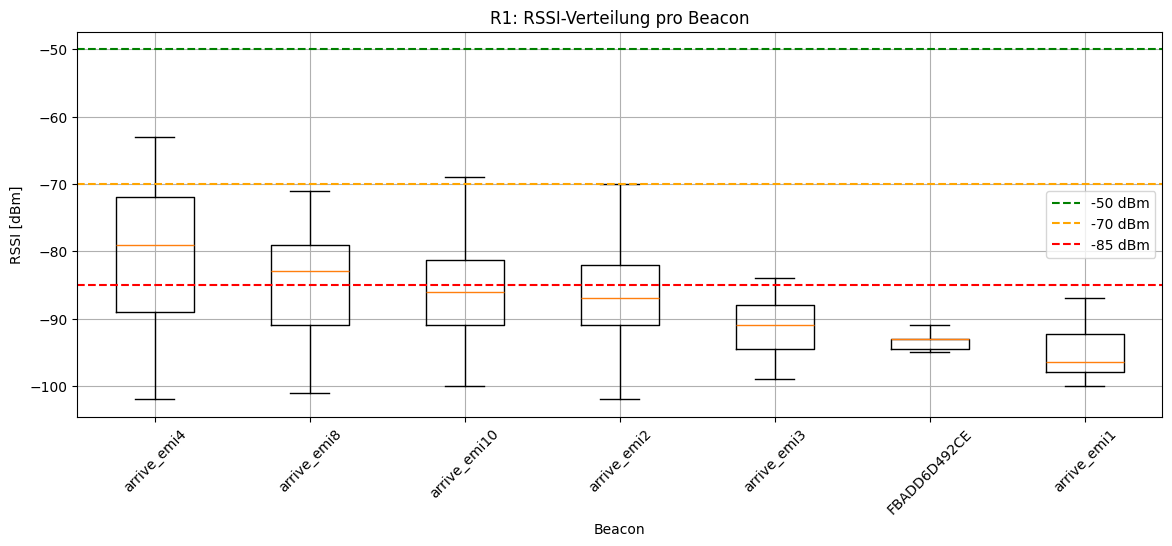

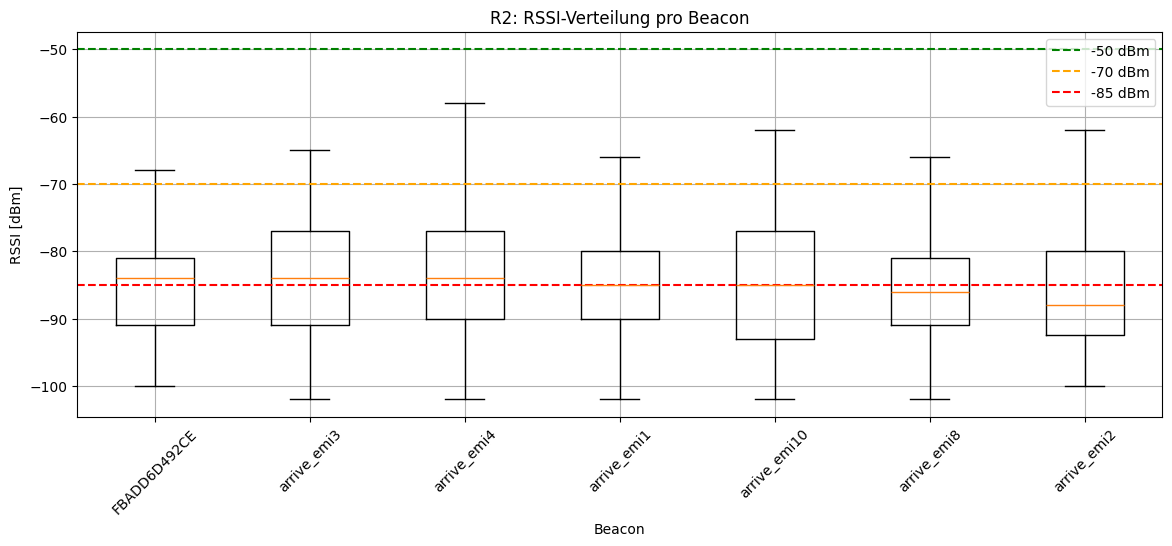

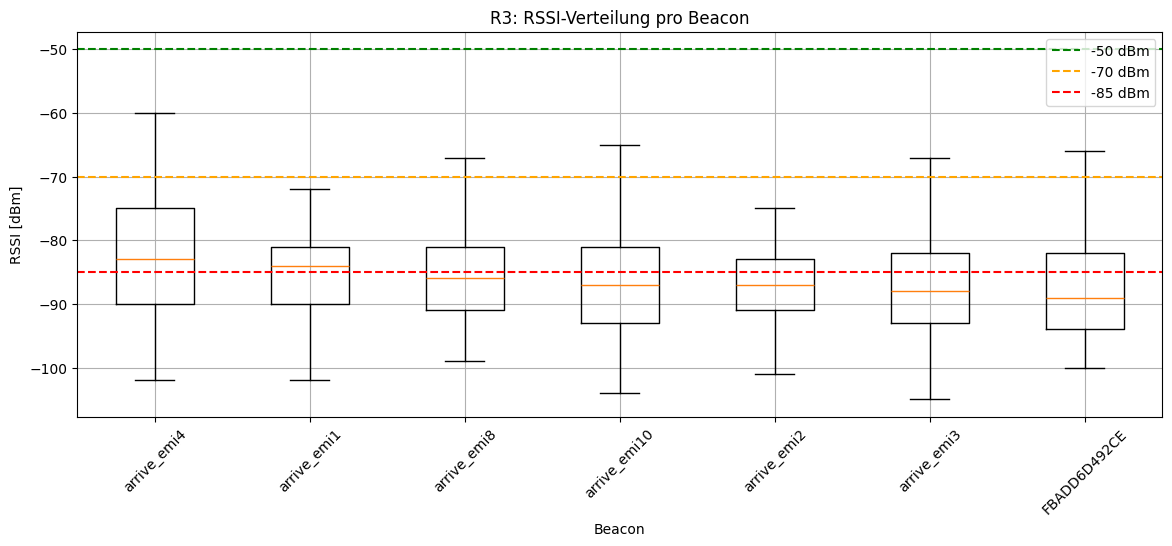

In [4]:
for run_id in RUN_IDS:
    run_ble = ble[ble["run_id"] == run_id]

    beacon_order = (
        run_ble.groupby("beacon_id")["rssi"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    data = [
        run_ble.loc[run_ble["beacon_id"] == beacon_id, "rssi"].dropna()
        for beacon_id in beacon_order
    ]

    plt.figure(figsize=(14, 5))
    plt.boxplot(data, tick_labels=beacon_order, showfliers=False)

    plt.axhline(-50, color="green", linestyle="--", label="-50 dBm")
    plt.axhline(-70, color="orange", linestyle="--", label="-70 dBm")
    plt.axhline(-85, color="red", linestyle="--", label="-85 dBm")

    plt.title(f"{run_id}: RSSI-Verteilung pro Beacon")
    plt.xlabel("Beacon")
    plt.ylabel("RSSI [dBm]")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

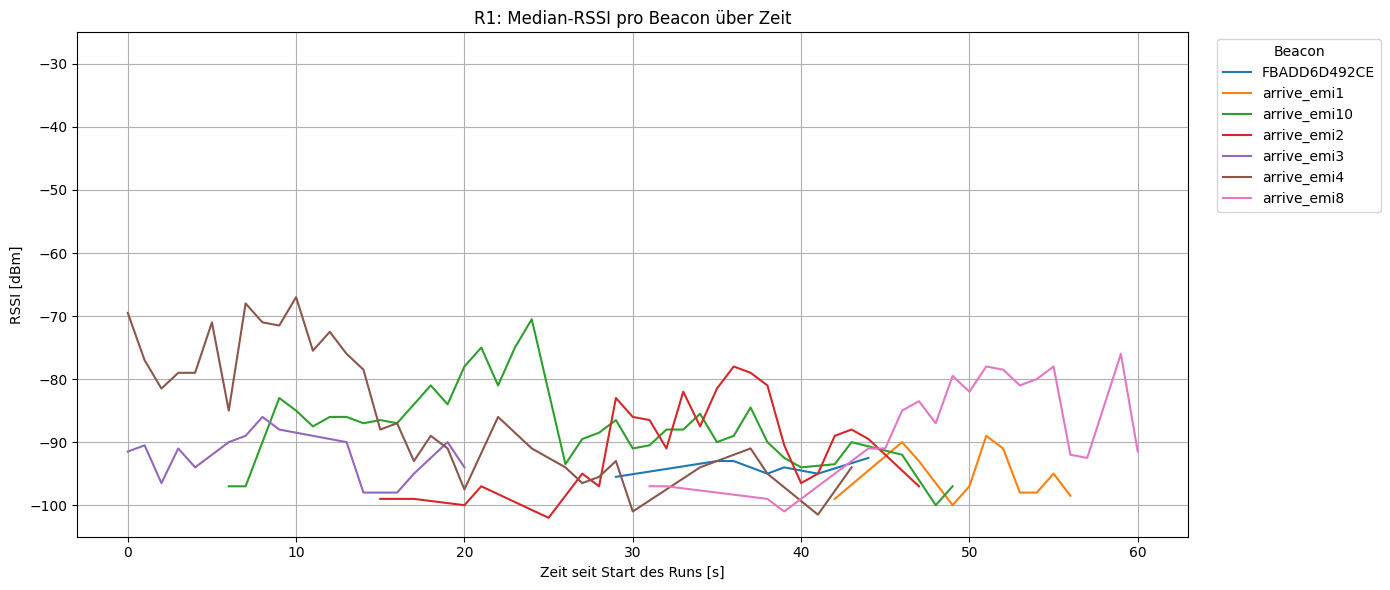

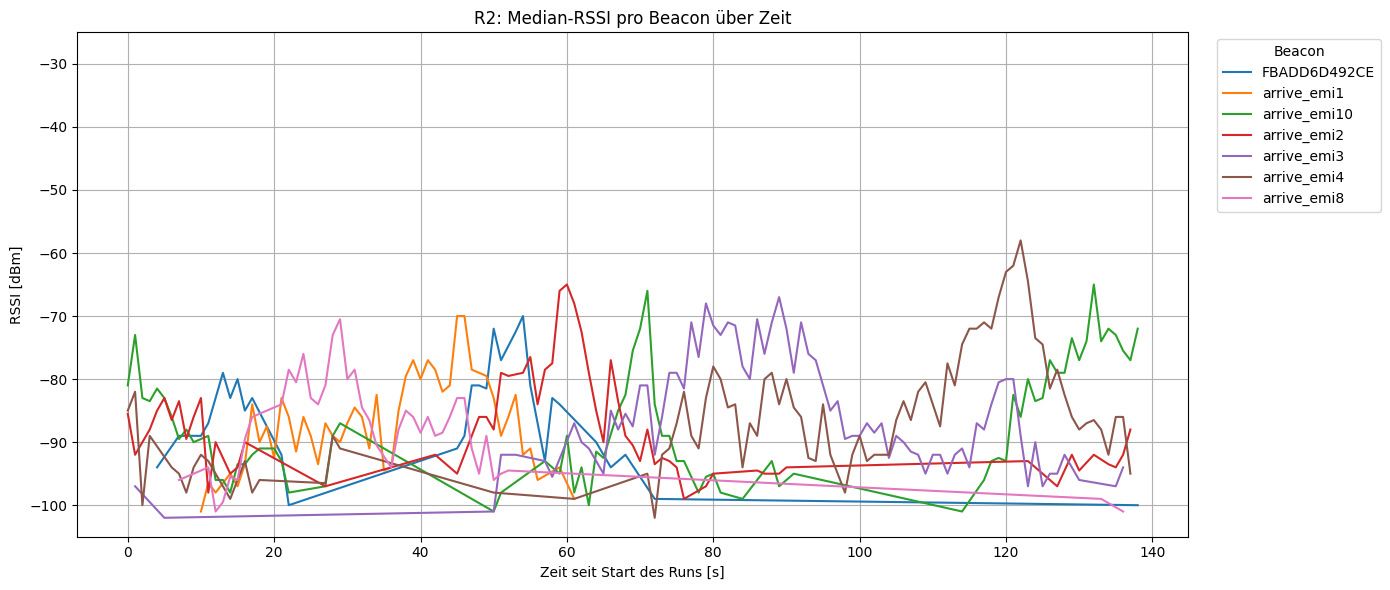

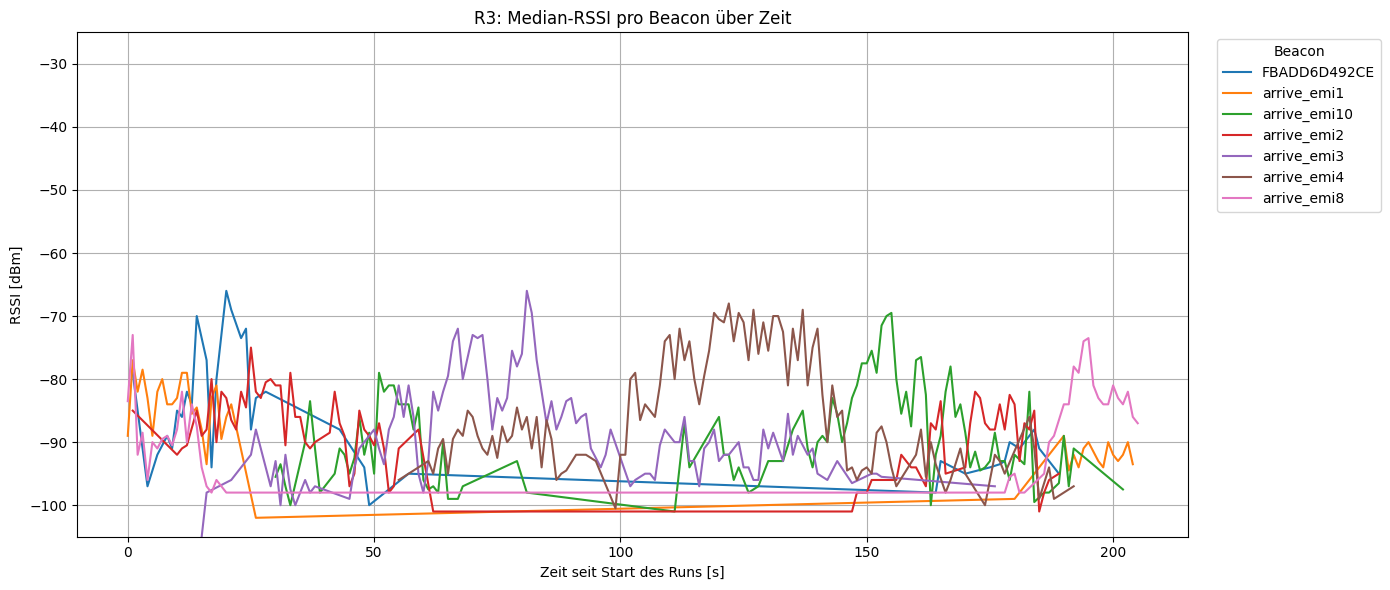

In [5]:
def aggregate_rssi_per_second(df, bin_size_s=1.0):
    """
    Fasst RSSI pro Beacon in Zeitfenstern zusammen.
    Der Median reduziert den Einfluss einzelner Ausreißer.
    """
    result = df.copy()

    start_time_s = result["time_s"].min()
    result["relative_time_s"] = result["time_s"] - start_time_s
    result["time_bin_s"] = (
        np.floor(result["relative_time_s"] / bin_size_s) * bin_size_s
    )

    return (
        result.groupby(["beacon_id", "time_bin_s"], as_index=False)["rssi"]
        .median()
        .sort_values(["beacon_id", "time_bin_s"])
    )


for run_id in RUN_IDS:
    run_ble = ble[ble["run_id"] == run_id].copy()
    rssi_binned = aggregate_rssi_per_second(run_ble, BIN_SIZE_S)

    plt.figure(figsize=(14, 6))

    for beacon_id, beacon_data in rssi_binned.groupby("beacon_id"):
        plt.plot(
            beacon_data["time_bin_s"],
            beacon_data["rssi"],
            linewidth=1.5,
            label=str(beacon_id),
        )

    plt.title(f"{run_id}: Median-RSSI pro Beacon über Zeit")
    plt.xlabel("Zeit seit Start des Runs [s]")
    plt.ylabel("RSSI [dBm]")
    plt.ylim(-105, -25)
    plt.legend(
        title="Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()

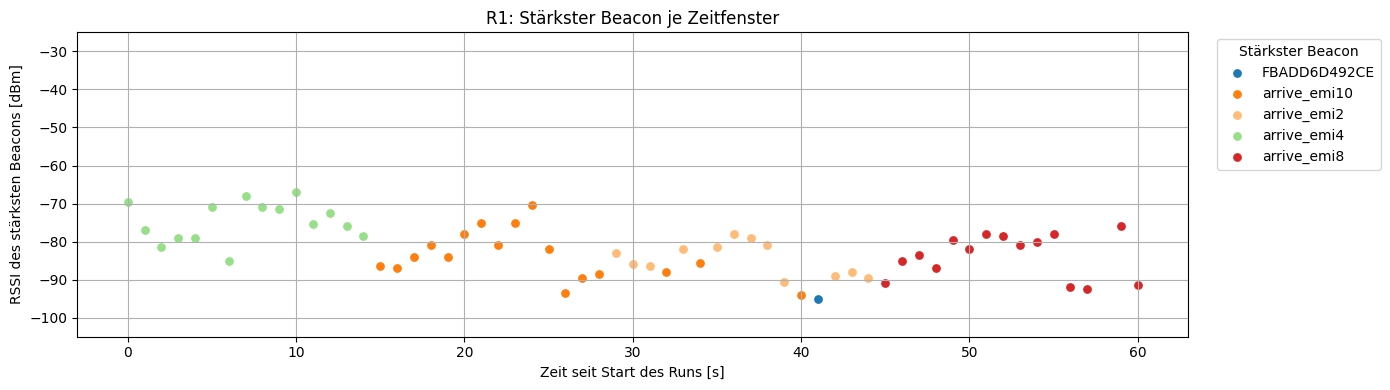

,time_bin_s,beacon_id,rssi
0,0.0,arrive_emi4,-69.5
1,1.0,arrive_emi4,-77.0
2,2.0,arrive_emi4,-81.5
3,3.0,arrive_emi4,-79.0
4,4.0,arrive_emi4,-79.0
5,5.0,arrive_emi4,-71.0
6,6.0,arrive_emi4,-85.0
7,7.0,arrive_emi4,-68.0
8,8.0,arrive_emi4,-71.0
9,9.0,arrive_emi4,-71.5


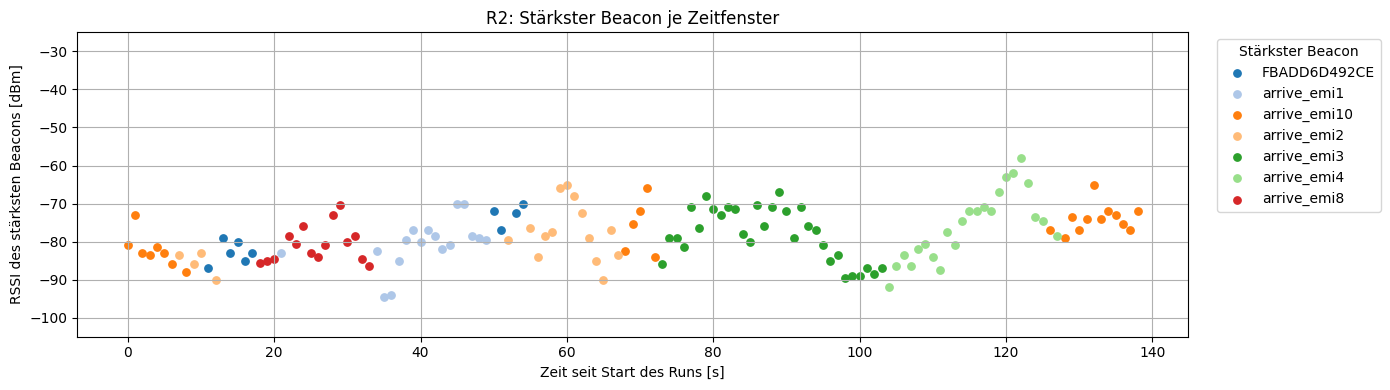

,time_bin_s,beacon_id,rssi
0,0.0,arrive_emi10,-81.0
1,1.0,arrive_emi10,-73.0
2,2.0,arrive_emi10,-83.0
3,3.0,arrive_emi10,-83.5
4,4.0,arrive_emi10,-81.5
5,5.0,arrive_emi10,-83.0
6,6.0,arrive_emi10,-86.0
7,7.0,arrive_emi2,-83.5
8,8.0,arrive_emi10,-88.0
9,9.0,arrive_emi2,-86.0


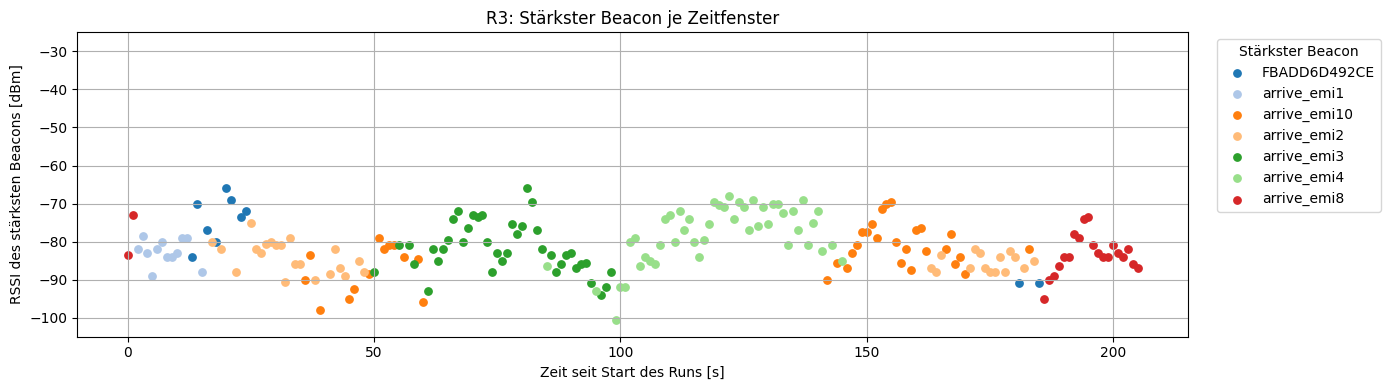

,time_bin_s,beacon_id,rssi
0,0.0,arrive_emi8,-83.5
1,1.0,arrive_emi8,-73.0
2,2.0,arrive_emi1,-82.0
3,3.0,arrive_emi1,-78.5
4,4.0,arrive_emi1,-83.0
5,5.0,arrive_emi1,-89.0
6,6.0,arrive_emi1,-82.0
7,7.0,arrive_emi1,-80.0
8,8.0,arrive_emi1,-84.0
9,9.0,arrive_emi1,-84.0


In [8]:
# Einheitliche Farben für alle Beacons
all_beacons = sorted(ble["beacon_id"].dropna().unique())
cmap = plt.get_cmap("tab20")

beacon_colors = {
    beacon_id: cmap(i % cmap.N)
    for i, beacon_id in enumerate(all_beacons)
}


for run_id in RUN_IDS:
    run_ble = ble[ble["run_id"] == run_id].copy()
    run_binned = aggregate_rssi_per_second(run_ble, BIN_SIZE_S)

    strongest_run = (
        run_binned
        .sort_values(["time_bin_s", "rssi"], ascending=[True, False])
        .groupby("time_bin_s", as_index=False)
        .first()
    )

    plt.figure(figsize=(14, 4))

    for beacon_id, beacon_data in strongest_run.groupby("beacon_id"):
        plt.scatter(
            beacon_data["time_bin_s"],
            beacon_data["rssi"],
            color=beacon_colors[beacon_id],
            s=28,
            label=str(beacon_id),
        )

    plt.title(f"{run_id}: Stärkster Beacon je Zeitfenster")
    plt.xlabel("Zeit seit Start des Runs [s]")
    plt.ylabel("RSSI des stärksten Beacons [dBm]")
    plt.ylim(-105, -25)

    plt.legend(
        title="Stärkster Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    display(
        strongest_run[["time_bin_s", "beacon_id", "rssi"]].head(15)
    )

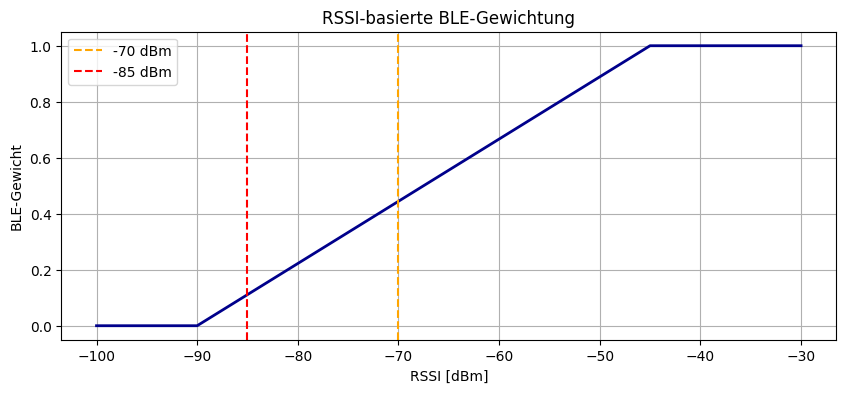

In [7]:
def rssi_to_weight(rssi, weak_rssi=-90, strong_rssi=-45):
    """
    Skaliert RSSI linear auf ein Gewicht zwischen 0 und 1.

    - <= -90 dBm: praktisch keine BLE-Evidenz
    - >= -45 dBm: maximale BLE-Evidenz
    """
    rssi = np.asarray(rssi, dtype=float)

    weight = (rssi - weak_rssi) / (strong_rssi - weak_rssi)
    return np.clip(weight, 0.0, 1.0)


rssi_values = np.arange(-100, -29, 1)
weights = rssi_to_weight(rssi_values)

plt.figure(figsize=(10, 4))
plt.plot(rssi_values, weights, color="darkblue", linewidth=2)
plt.axvline(-70, color="orange", linestyle="--", label="-70 dBm")
plt.axvline(-85, color="red", linestyle="--", label="-85 dBm")

plt.title("RSSI-basierte BLE-Gewichtung")
plt.xlabel("RSSI [dBm]")
plt.ylabel("BLE-Gewicht")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()